In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


In [29]:
# Display settings
pd.set_option("display.max_columns", None)

df = pd.read_csv('/content/Customer_support_data.csv')

print("Dataset Shape :", df.shape)
print("\nColumns:\n")
print(df.columns.tolist())

df.head()

Dataset Shape : (85907, 20)

Columns:

['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [30]:
# Create a copy
df_ml = df.copy()

# Remove unnecessary columns
drop_cols = [
    "Unique id",
    "Order_id",
    "Customer Remarks",
    "Agent_name",
    "Supervisor",
    "Manager"
]

df_ml.drop(columns=drop_cols, inplace=True)

print(df_ml.shape)
df_ml.head()

(85907, 14)


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,channel_name,category,Sub-category,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Tenure Bucket,Agent Shift,CSAT Score
0,Outcall,Product Queries,Life Insurance,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,On Job Training,Morning,5
1,Outcall,Product Queries,Product Specific Information,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,>90,Morning,5
2,Inbound,Order Related,Installation/demo,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,On Job Training,Evening,5
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,>90,Evening,5
4,Inbound,Cancellation,Not Needed,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,0-30,Morning,5


In [31]:
date_cols = [
    "Issue_reported at",
    "issue_responded",
    "Survey_response_Date"
]

for col in date_cols:
    df_ml[col] = pd.to_datetime(df_ml[col], errors="coerce", dayfirst=True)

    df_ml[col+"_day"] = df_ml[col].dt.day
    df_ml[col+"_month"] = df_ml[col].dt.month
    df_ml[col+"_hour"] = df_ml[col].dt.hour

df_ml.drop(columns=date_cols, inplace=True)

df_ml.head()

/tmp/ipykernel_1030/1851568568.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ml[col] = pd.to_datetime(df_ml[col], errors="coerce", dayfirst=True)
/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,channel_name,category,Sub-category,order_date_time,Customer_City,Product_category,Item_price,connected_handling_time,Tenure Bucket,Agent Shift,CSAT Score,Issue_reported at_day,Issue_reported at_month,Issue_reported at_hour,issue_responded_day,issue_responded_month,issue_responded_hour,Survey_response_Date_day,Survey_response_Date_month,Survey_response_Date_hour
0,Outcall,Product Queries,Life Insurance,NaN,NaN,NaN,NaN,NaN,On Job Training,Morning,5,1,8,11,1,8,11,1,8,0
1,Outcall,Product Queries,Product Specific Information,NaN,NaN,NaN,NaN,NaN,>90,Morning,5,1,8,12,1,8,12,1,8,0
2,Inbound,Order Related,Installation/demo,NaN,NaN,NaN,NaN,NaN,On Job Training,Evening,5,1,8,20,1,8,20,1,8,0
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,NaN,NaN,NaN,NaN,>90,Evening,5,1,8,20,1,8,21,1,8,0
4,Inbound,Cancellation,Not Needed,NaN,NaN,NaN,NaN,NaN,0-30,Morning,5,1,8,10,1,8,10,1,8,0


In [32]:
for col in df_ml.columns:

    if df_ml[col].dtype == "object":
        df_ml[col].fillna(df_ml[col].mode()[0], inplace=True)

    else:
        df_ml[col].fillna(df_ml[col].median(), inplace=True)

df_ml.isnull().sum()

/tmp/ipykernel_1030/229403870.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml[col].fillna(df_ml[col].mode()[0], inplace=True)
/tmp/ipykernel_1030/229403870.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

,0
channel_name,0
category,0
Sub-category,0
order_date_time,0
Customer_City,0
Product_category,0
Item_price,0
connected_handling_time,0
Tenure Bucket,0
Agent Shift,0


In [33]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df_ml.select_dtypes(include="object").columns:
    df_ml[col] = encoder.fit_transform(df_ml[col])

df_ml.head()

,channel_name,category,Sub-category,order_date_time,Customer_City,Product_category,Item_price,connected_handling_time,Tenure Bucket,Agent Shift,CSAT Score,Issue_reported at_day,Issue_reported at_month,Issue_reported at_hour,issue_responded_day,issue_responded_month,issue_responded_hour,Survey_response_Date_day,Survey_response_Date_month,Survey_response_Date_hour
0,2,8,19,5222,684,2,979.0,427.0,4,2,5,1,8,11,1,8,11,1,8,0
1,2,8,34,5222,684,2,979.0,427.0,3,2,5,1,8,12,1,8,12,1,8,0
2,1,5,15,5222,684,2,979.0,427.0,4,1,5,1,8,20,1,8,20,1,8,0
3,1,10,40,5222,684,2,979.0,427.0,3,1,5,1,8,20,1,8,21,1,8,0
4,1,1,22,5222,684,2,979.0,427.0,0,2,5,1,8,10,1,8,10,1,8,0


In [34]:
# Remove columns with very high missing values or no useful information
df_ml.drop(columns=["order_date_time"], inplace=True)

print(df_ml.shape)

(85907, 19)


In [35]:
print(df_ml.isnull().sum())

channel_name                  0
category                      0
Sub-category                  0
Customer_City                 0
Product_category              0
Item_price                    0
connected_handling_time       0
Tenure Bucket                 0
Agent Shift                   0
CSAT Score                    0
Issue_reported at_day         0
Issue_reported at_month       0
Issue_reported at_hour        0
issue_responded_day           0
issue_responded_month         0
issue_responded_hour          0
Survey_response_Date_day      0
Survey_response_Date_month    0
Survey_response_Date_hour     0
dtype: int64


In [36]:
# Train-Test Split)
from sklearn.model_selection import train_test_split

X = df_ml.drop("CSAT Score", axis=1)
y = df_ml["CSAT Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(68725, 18)
(17182, 18)


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred) * 100

print(f"Decision Tree Accuracy: {dt_accuracy:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 66.09%

Classification Report:

              precision    recall  f1-score   support

           1       0.25      0.11      0.16      2246
           2       0.08      0.00      0.01       256
           3       0.08      0.01      0.01       512
           4       0.14      0.03      0.05      2244
           5       0.70      0.93      0.80     11924

    accuracy                           0.66     17182
   macro avg       0.25      0.22      0.20     17182
weighted avg       0.54      0.66      0.58     17182



In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred) * 100

print(f"Random Forest Accuracy: {rf_accuracy:.2f}%")

Random Forest Accuracy: 56.36%


In [39]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "n_estimators": [200, 300, 400],
    "max_depth": [15, 20, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    param_distributions=params,
    n_iter=8,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

best_pred = best_model.predict(X_test)

best_accuracy = accuracy_score(y_test, best_pred) * 100

print(f"Best Tuned Random Forest Accuracy: {best_accuracy:.2f}%")

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Tuned Random Forest Accuracy: 60.16%


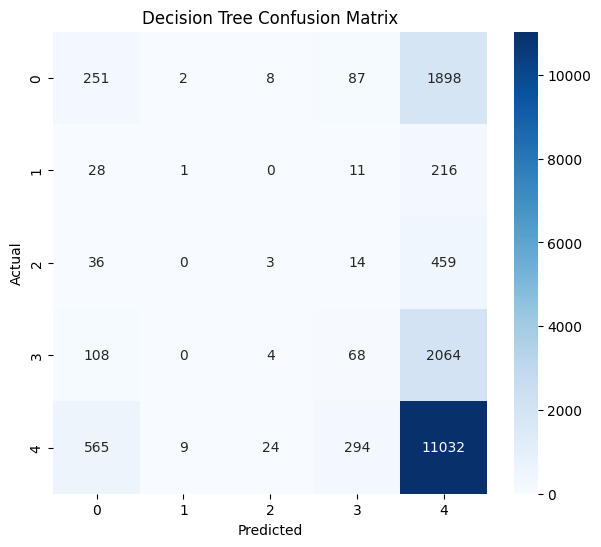

In [40]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(7,6))

cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

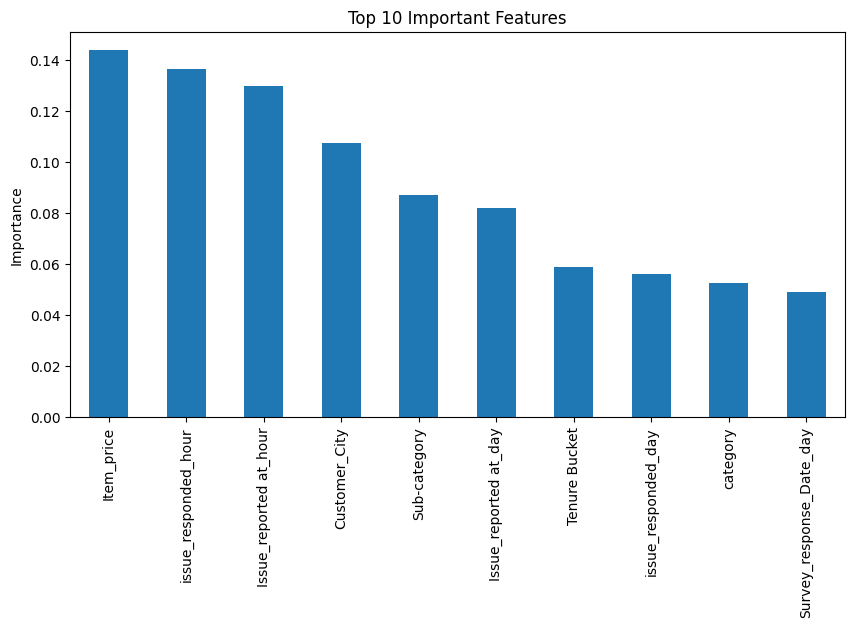

In [41]:
importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,5))

importance.head(10).plot(kind='bar')

plt.title("Top 10 Important Features")

plt.ylabel("Importance")

plt.show()

In [42]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy (%)":[
        dt_accuracy,
        rf_accuracy,
        best_accuracy
    ]

})

comparison

,Model,Accuracy (%)
0,Decision Tree,66.086602
1,Random Forest,56.361308
2,Tuned Random Forest,60.155977


In [43]:
best_model_name = comparison.loc[
    comparison["Accuracy (%)"].idxmax(),
    "Model"
]

best_model_accuracy = comparison["Accuracy (%)"].max()

print(f"Best Model: {best_model_name}")
print(f"Best Accuracy: {best_model_accuracy:.2f}%")

Best Model: Decision Tree
Best Accuracy: 66.09%
